In [1]:
pip install scikit-fuzzy

Note: you may need to restart the kernel to use updated packages.


   Age  Cholesterol       Risk
0   25          120  16.538462
1   35          160  37.909636
2   45          190  50.000000
3   55          210  50.000000
4   65          240  67.884848
5   75          270  85.303030
6   85          300  86.666667

Insight: Semakin tua usia dan semakin tinggi kolesterol, semakin tinggi tingkat risiko penyakit.



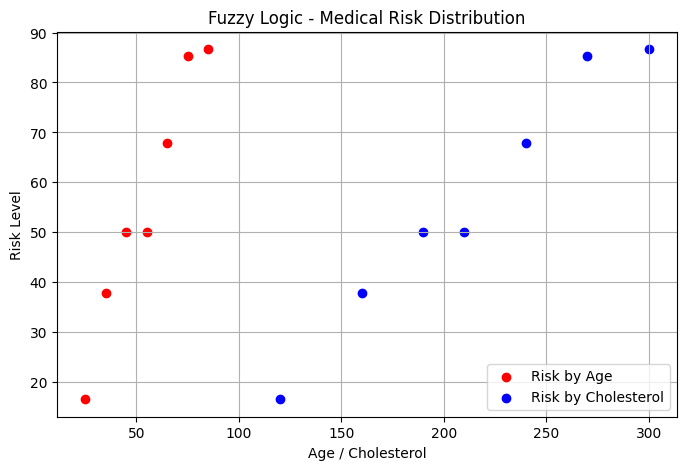

In [17]:
# --- 1. Import Library ---
import numpy as np
import pandas as pd
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

# --- 2. Definisikan Variabel Fuzzy ---
age = ctrl.Antecedent(np.arange(0, 101, 1), 'age')
cholesterol = ctrl.Antecedent(np.arange(100, 301, 1), 'cholesterol')
risk = ctrl.Consequent(np.arange(0, 101, 1), 'risk')  # nama output sesuai 'risk'

# --- 3. Membership Function ---
age['young'] = fuzz.trimf(age.universe, [0, 0, 40])
age['middle'] = fuzz.trimf(age.universe, [30, 50, 70])
age['old'] = fuzz.trimf(age.universe, [60, 100, 100])

cholesterol['low'] = fuzz.trimf(cholesterol.universe, [100, 100, 180])
cholesterol['medium'] = fuzz.trimf(cholesterol.universe, [150, 200, 250])
cholesterol['high'] = fuzz.trimf(cholesterol.universe, [220, 300, 300])

risk['low'] = fuzz.trimf(risk.universe, [0, 0, 40])
risk['medium'] = fuzz.trimf(risk.universe, [30, 50, 70])
risk['high'] = fuzz.trimf(risk.universe, [60, 100, 100])

# --- 4. Aturan Fuzzy ---
rule1 = ctrl.Rule(age['young'] & cholesterol['low'], risk['low'])
rule2 = ctrl.Rule(age['middle'] & cholesterol['medium'], risk['medium'])
rule3 = ctrl.Rule(age['old'] | cholesterol['high'], risk['high'])
rule4 = ctrl.Rule(age['middle'] & cholesterol['high'], risk['high'])
rule5 = ctrl.Rule(age['old'] & cholesterol['medium'], risk['high'])

# --- 5. Sistem Kontrol ---
risk_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5])
risk_sim = ctrl.ControlSystemSimulation(risk_ctrl)

# --- 6. Dataset (contoh sederhana, bisa diganti CSV kamu) ---
f = pd.read_csv('./data/diabetes.zip')

# Pastikan kolom yang dipakai sesuai dataset
df = df.rename(columns={'age': 'Age', 'chol': 'Cholesterol'})

# Ambil hanya kolom yang dibutuhkan
df = df[['Age', 'Cholesterol']]

# --- 7. Jalankan Fuzzy Logic ---
fuzzy_risks = []
for _, row in df.iterrows():
    risk_sim.input['age'] = row['Age']
    risk_sim.input['cholesterol'] = row['Cholesterol']
    risk_sim.compute()
    fuzzy_risks.append(risk_sim.output['risk'])  # sudah cocok dengan nama Consequent

df['Risk'] = fuzzy_risks

# --- 8. Insight Baru ---
print(df)
print("\nInsight: Semakin tua usia dan semakin tinggi kolesterol, semakin tinggi tingkat risiko penyakit.\n")

# --- 9. Plot Distribusi ---
plt.figure(figsize=(8,5))
plt.scatter(df['Age'], df['Risk'], color='red', label='Risk by Age')
plt.scatter(df['Cholesterol'], df['Risk'], color='blue', label='Risk by Cholesterol')
plt.title("Fuzzy Logic - Medical Risk Distribution")
plt.xlabel("Age / Cholesterol")
plt.ylabel("Risk Level")
plt.legend()
plt.grid(True)
plt.show()


In [15]:
pip freeze

absl-py==2.3.1
annotated-types==0.7.0
anyio==4.10.0
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
arrow==1.3.0
asttokens==3.0.0
astunparse==1.6.3
async-lru==2.0.5
attrs==25.3.0
babel==2.17.0
beautifulsoup4==4.13.5
bleach==6.2.0
blinker==1.9.0
certifi==2025.8.3
cffi==2.0.0
charset-normalizer==3.4.3
click==8.3.0
colorama==0.4.6
comm==0.2.3
contourpy==1.3.2
cycler==0.12.1
debugpy==1.8.17
decorator==5.2.1
defusedxml==0.7.1
exceptiongroup==1.3.0
executing==2.2.1
fastapi==0.117.1
fastjsonschema==2.21.2
filelock==3.13.1
Flask==3.1.2
flatbuffers==25.2.10
fonttools==4.60.0
fqdn==1.5.1
fsspec==2024.6.1
gast==0.6.0
google-pasta==0.2.0
grpcio==1.75.0
h11==0.16.0
h5py==3.14.0
Note: you may need to restart the kernel to use updated packages.
httpcore==1.0.9
httptools==0.6.4
httpx==0.28.1
huggingface-hub==0.35.0
idna==3.10
ipykernel==6.30.1
ipython==8.37.0
ipywidgets==8.1.7
isoduration==20.11.0
itsdangerous==2.2.0
jedi==0.19.2
Jinja2==3.1.6
joblib==1.5.2
json5==0.12.1
jsonpointer==3.0.0
jsonschema